# The Hanging Chain: a Pendulum Whose Modes are Bessel Functions

A flexible chain hangs under gravity, fixed at the top and free to swing at the bottom — a
*continuous pendulum*. Daniel Bernoulli solved its small oscillations in **1732**, and in doing so
wrote down the **first Bessel function in physics**, decades before Bessel.

The key: the tension is not constant. At height $x$ above the free end the chain supports the weight
below it, so $T(x)=\mu g x$. The transverse wave equation $\partial_x(T\,\partial_x y)=\mu\,\partial_t^2 y$
becomes, for a mode $y=u(x)\cos\omega t$,

$$g\,(x\,u')' + \omega^2 u = 0,$$

which is **Bessel's equation of order 0**. Regularity at the bottom keeps $J_0$; the fixed top
quantizes the frequencies through the **zeros of $J_0$**. Built on `griffiths.bessel` (from the
cylindrical separation-of-variables notebook).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from griffiths import bessel as bz

L, g = 1.0, 9.81
print("griffiths.bessel loaded; chain length L =", L, "m")

griffiths.bessel loaded; chain length L = 1.0 m


## §1 The natural frequencies are the zeros of $J_0$

The fixed top, $u(L)=0$, demands $J_0\!\big(2\omega\sqrt{L/g}\big)=0$, so $2\omega\sqrt{L/g}$ must be a
zero $\alpha_{0,n}$ of $J_0$:

$$\boxed{\ \omega_n=\frac{\alpha_{0,n}}{2}\sqrt{\frac{g}{L}}\ },\qquad
\alpha_{0,n}=2.405,\ 5.520,\ 8.654,\dots$$

The overtones are **not** harmonic — their ratios are the (anharmonic) ratios of $J_0$'s zeros, which
is why a swinging chain sounds and looks different from a vibrating string.

In [2]:
freqs, zeros = bz.hanging_chain_frequencies(L, g, 5)
print("J_0 zeros alpha_n :", np.round(zeros, 4))
print("frequencies omega :", np.round(freqs, 4), "rad/s")
print("overtone ratios   :", np.round(np.array(freqs)/freqs[0], 3),
      " (string would be 1,2,3,4,5 -- chain is anharmonic)")

J_0 zeros alpha_n : [ 2.4048  5.5201  8.6537 11.7915 14.9309]
frequencies omega : [ 3.7661  8.6447 13.5521 18.4661 23.3825] rad/s
overtone ratios   : [1.    2.295 3.598 4.903 6.209]  (string would be 1,2,3,4,5 -- chain is anharmonic)


## §2 The mode shapes

Each mode is $u_n(x)=J_0\!\big(\alpha_{0,n}\sqrt{x/L}\big)$: maximum swing at the free bottom,
pinned at the top, with $n-1$ internal nodes. Drawn as the chain actually hangs (height vertical,
transverse displacement horizontal):

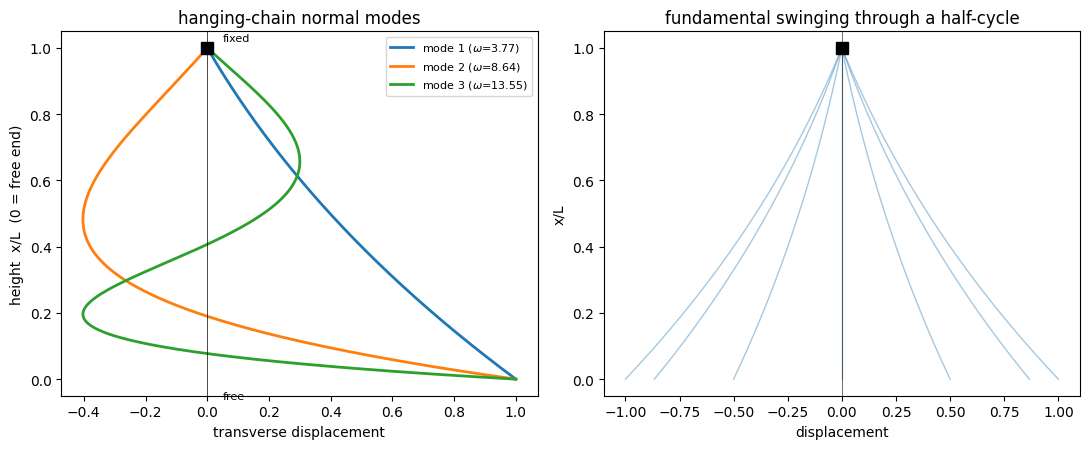

In [3]:
xfrac = np.linspace(0, 1, 400)            # x/L, 0 = free bottom, 1 = fixed top
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for n in range(3):
    u = bz.hanging_chain_modeshape(zeros[n], xfrac)
    u = u / np.max(np.abs(u))             # normalize amplitude
    ax[0].plot(u, xfrac, lw=2, label=f"mode {n+1} ($\\omega$={freqs[n]:.2f})")
ax[0].axvline(0, color="k", lw=0.5); ax[0].plot(0, 1, "ks", ms=8)
ax[0].set_xlabel("transverse displacement"); ax[0].set_ylabel("height  x/L  (0 = free end)")
ax[0].set_title("hanging-chain normal modes"); ax[0].legend(fontsize=8)
ax[0].text(0.05, 1.02, "fixed", fontsize=8); ax[0].text(0.05, -0.06, "free", fontsize=8)

# a few snapshots of the fundamental swinging
u1 = bz.hanging_chain_modeshape(zeros[0], xfrac); u1 /= np.max(np.abs(u1))
for ph in np.linspace(0, np.pi, 7):
    ax[1].plot(u1 * np.cos(ph), xfrac, color="C0", alpha=0.4, lw=1)
ax[1].plot(0, 1, "ks", ms=8); ax[1].axvline(0, color="k", lw=0.4)
ax[1].set_xlabel("displacement"); ax[1].set_ylabel("x/L")
ax[1].set_title("fundamental swinging through a half-cycle")
plt.tight_layout(); plt.show()

## §3 Verification: a finite-difference eigensolver, no Bessel assumed

Discretize $-(x\,u')'=\lambda u$ (with $\lambda=\omega^2/g$, $u(L)=0$, regular at $x=0$) and solve the
eigenvalue problem numerically. The frequencies it returns match the $J_0$-zero formula to a fraction
of a percent — the Bessel result is exact, the discretization is the only error.

Bessel (J_0 zeros): [ 3.7661  8.6447 13.5521 18.4661 23.3825]
finite difference : [ 3.7652  8.64   13.5405 18.4442 23.347 ]
max relative error: 1.52e-03


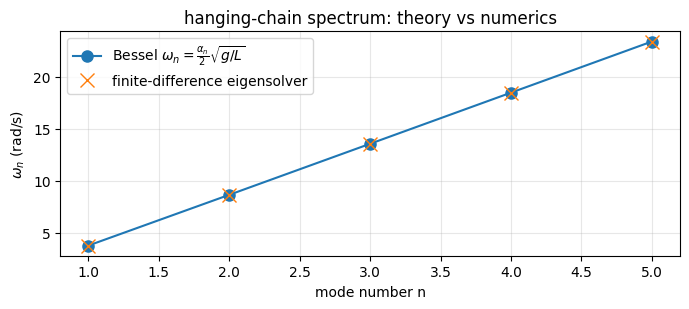

In [4]:
N = 4000
x = np.linspace(0, L, N + 1); h = x[1] - x[0]
xmid = 0.5 * (x[:-1] + x[1:])
main = np.zeros(N); lower = np.zeros(N - 1); upper = np.zeros(N - 1)
for i in range(N):
    pL = xmid[i - 1] if i > 0 else 0.0    # p(x)=x vanishes at the singular bottom
    pR = xmid[i]
    main[i] = (pL + pR) / h**2
    if i > 0:
        lower[i - 1] = -pL / h**2
    if i < N - 1:
        upper[i] = -pR / h**2
A = np.diag(main) + np.diag(lower, -1) + np.diag(upper, 1)
omega_fd = np.sqrt(g * np.sort(np.linalg.eigvalsh(A))[:5])
print("Bessel (J_0 zeros):", np.round(freqs, 4))
print("finite difference :", np.round(omega_fd, 4))
print("max relative error:", f"{np.max(np.abs(omega_fd - freqs)/np.array(freqs)):.2e}")

plt.figure(figsize=(7, 3.2))
idx = np.arange(1, 6)
plt.plot(idx, freqs, "o-", ms=8, label="Bessel $\\omega_n=\\frac{\\alpha_n}{2}\\sqrt{g/L}$")
plt.plot(idx, omega_fd, "x", ms=10, label="finite-difference eigensolver")
plt.xlabel("mode number n"); plt.ylabel("$\\omega_n$ (rad/s)"); plt.legend()
plt.title("hanging-chain spectrum: theory vs numerics"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §4 The pendulum connection, and Bessel everywhere

- **Continuous vs point pendulum.** A simple pendulum (all mass at the bottom) swings at
  $\omega=\sqrt{g/L}$. The chain's fundamental is $\omega_1=\tfrac{\alpha_1}{2}\sqrt{g/L}\approx
  1.20\sqrt{g/L}$ — stiffer, because the distributed mass higher up feels more tension. The chain is
  the pendulum's continuum cousin, and $J_0$ is what the continuum limit costs you.

In [5]:
omega_simple = np.sqrt(g / L)
print(f"simple pendulum   omega = sqrt(g/L)      = {omega_simple:.3f} rad/s")
print(f"chain fundamental omega = (alpha_1/2)... = {freqs[0]:.3f} rad/s")
print(f"ratio = {freqs[0]/omega_simple:.4f} = alpha_1/2 = {zeros[0]/2:.4f}")

simple pendulum   omega = sqrt(g/L)      = 3.132 rad/s
chain fundamental omega = (alpha_1/2)... = 3.766 rad/s
ratio = 1.2024 = alpha_1/2 = 1.2024


- **Same $J_0$, three places.** The zeros of $J_0$ that quantize this chain are the *same* numbers
  that set the cutoff of the step-index fibre LP modes and the drumhead frequencies in the Bessel
  notebook — one special function, three boundary-value problems.
- **Why the repo cares.** The chain is the cleanest example of a continuous oscillator with
  non-uniform "stiffness" (here, position-dependent tension); the dispersive fibre the TD-GS pipeline
  uses is the optical analog — a propagation constant that varies across the mode, with the same
  Bessel/Sturm-Liouville machinery underneath.

Engine: `griffiths/bessel.py` gained `hanging_chain_frequencies` and `hanging_chain_modeshape`
(verified in `scripts/smoke_hanging_chain.py` against a finite-difference eigensolver to 0.15%).